# Bai tap: ETHUSDs (Forex)/ ETHUSDT 1m tren Forex hoac Binace
### Mot chien luoc mua: Khi gia du doan > Gia thuc te va MA 10 > MA 20
### Mot chien luoc ban: Khi gia du doan < Gia thuc te va MA 10 < MA 20

In [ ]:
# Den 21h25

# Buoc 1: Load data

In [1]:
import sys
sys.path.append('../Common')

import CommonMT5DWH
import MetaTrader5 as mt5

symbol = 'EURUSD.sml'
from_date = '2024-01-01'
to_date = '2024-12-06' # yyyy-mm-dd
interval = mt5.TIMEFRAME_D1

data = CommonMT5DWH.CommonMT5DWH.loaddataMT5_FromTo_List_Ext(symbol, from_date, to_date, interval)

data

,Symbol,Datetime,Open,High,Low,Close,Volume
0,EURUSD.sml,2024-01-02,1.10439,1.10452,1.09383,1.09407,130997
1,EURUSD.sml,2024-01-03,1.09460,1.09655,1.08930,1.09220,159369
2,EURUSD.sml,2024-01-04,1.09171,1.09724,1.09160,1.09450,135799
3,EURUSD.sml,2024-01-05,1.09487,1.09987,1.08769,1.09423,186239
4,EURUSD.sml,2024-01-08,1.09487,1.09789,1.09226,1.09506,124877
...,...,...,...,...,...,...,...
238,EURUSD.sml,2024-11-29,1.05521,1.05974,1.05416,1.05779,240058
239,EURUSD.sml,2024-12-02,1.05688,1.05709,1.04606,1.04978,280542
240,EURUSD.sml,2024-12-03,1.04986,1.05352,1.04806,1.05095,212669
241,EURUSD.sml,2024-12-04,1.05067,1.05443,1.04724,1.05103,231249


# Buoc 2: Dua vao data:
### Tinh ra chi bao MA10, MA20
### Du doan dua va Hoi quy tuyen tinh
### Tinh Buy_Signal, Sell_Signal
### Day qua Redis

c:\Users\PCDTT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\PCDTT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\PCDTT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\PCDTT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\PCDTT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid fea

      Datetime    Close  Predicted_Close
0   2024-01-02  1.09407              NaN
1   2024-01-03  1.09220              NaN
2   2024-01-04  1.09450              NaN
3   2024-01-05  1.09423              NaN
4   2024-01-08  1.09506              NaN
..         ...      ...              ...
238 2024-11-29  1.05779         1.085928
239 2024-12-02  1.04978         1.070922
240 2024-12-03  1.05095         1.078506
241 2024-12-04  1.05103         1.088431
242 2024-12-05  1.05877         1.083983

[243 rows x 3 columns]


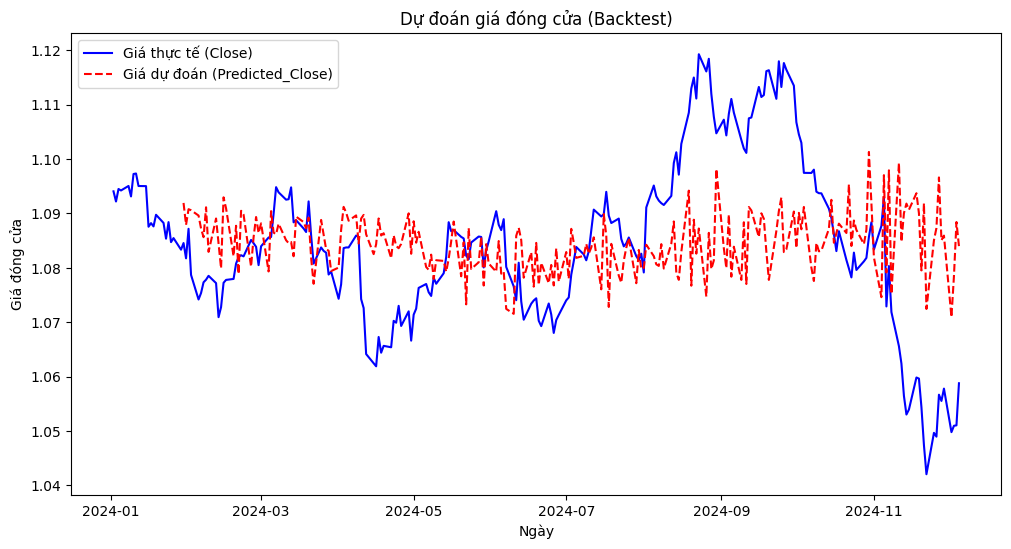

In [2]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Tạo đặc trưng
data['Open-Close'] = data['Open'] - data['Close']
data['High-Low'] = data['High'] - data['Low']

# Chuẩn bị cột dự đoán
data['Predicted_Close'] = np.nan

# Rolling prediction
rolling_window = 20  # Số bản ghi tối thiểu để bắt đầu dự đoán
for i in range(rolling_window, len(data)):
    # Lấy dữ liệu trước điểm hiện tại làm tập huấn luyện
    train_data = data.iloc[:i]
    
    # Đặc trưng và mục tiêu
    X_train = train_data[['Open-Close', 'High-Low']]
    y_train = train_data['Close']
    
    # Đặc trưng của bản ghi hiện tại để dự đoán
    X_test = data[['Open-Close', 'High-Low']].iloc[i].values.reshape(1, -1)
    
    # Huấn luyện mô hình Random Forest
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    
    # Dự đoán giá đóng cửa
    data.loc[i, 'Predicted_Close'] = model.predict(X_test)[0]

# Kiểm tra kết quả
print(data[['Datetime', 'Close', 'Predicted_Close']])
data.to_csv('D:/data.csv')

# Vẽ biểu đồ để minh họa
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data['Datetime'], data['Close'], label='Giá thực tế (Close)', color='blue')
plt.plot(data['Datetime'], data['Predicted_Close'], label='Giá dự đoán (Predicted_Close)', color='red', linestyle='--')
plt.title('Dự đoán giá đóng cửa (Backtest)')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa')
plt.legend()
plt.show()


In [4]:
data

,Symbol,Datetime,Open,High,Low,Close,Volume,Open-Close,High-Low,Predicted_Close
0,EURUSD.sml,2024-01-02,1.10439,1.10452,1.09383,1.09407,130997,0.01032,0.01069,NaN
1,EURUSD.sml,2024-01-03,1.09460,1.09655,1.08930,1.09220,159369,0.00240,0.00725,NaN
2,EURUSD.sml,2024-01-04,1.09171,1.09724,1.09160,1.09450,135799,-0.00279,0.00564,NaN
3,EURUSD.sml,2024-01-05,1.09487,1.09987,1.08769,1.09423,186239,0.00064,0.01218,NaN
4,EURUSD.sml,2024-01-08,1.09487,1.09789,1.09226,1.09506,124877,-0.00019,0.00563,NaN
...,...,...,...,...,...,...,...,...,...,...
238,EURUSD.sml,2024-11-29,1.05521,1.05974,1.05416,1.05779,240058,-0.00258,0.00558,1.085928
239,EURUSD.sml,2024-12-02,1.05688,1.05709,1.04606,1.04978,280542,0.00710,0.01103,1.070922
240,EURUSD.sml,2024-12-03,1.04986,1.05352,1.04806,1.05095,212669,-0.00109,0.00546,1.078506
241,EURUSD.sml,2024-12-04,1.05067,1.05443,1.04724,1.05103,231249,-0.00036,0.00719,1.088431


# Du doan tuong lai